# One-Notebook Repro Pack (Paper-Grade)

**Goal:** a *single* notebook that is sufficient to reproduce the paper claims and pre-empt common reviewer critiques.

### What this notebook delivers
1. **Compilable NVCC kernel** (fused gather-sum) inside the notebook
2. **Dense baselines** (SDPA math + SDPA flash when available)
3. **Sparse fused decode** (routing + EG/FW + fused kernel)
4. **Quality**: windowed **PPL** delta + **needle-in-a-haystack**
5. **Scaling**: TPOT/throughput vs context length up to **128k**
6. **Ablations**: solver {EG, FW}, sweep (P, Kc)
7. **Paper-ready export**: `tables/*.csv`, `plots/*.pdf|png`, `logs/*.txt`, and a zip bundle

> Recommended hardware: **H100 (SM90)**. Works on A100 with minor arch change.


# Reproducibility Guide (Paper ↔ Notebook)

This notebook is the **single entry point** to reproduce the *empirical artifacts used in the paper*:
figures, CSV tables, and the exact files included by the TeX build.

## Paper → Notebook mapping

| Paper item | TeX label / filename | Notebook section (heading) | Output produced |
|---|---|---|---|
| Figure 1 (decode scaling) | `plots/figure_decode_scaling.pdf` | **Decode scaling benchmark** | `plots/figure_decode_scaling.{pdf,png}` + `tables/scaling_decode.csv` |
| Table 2 (latency / speedup) | built from `tables/scaling_decode.csv` | **Decode scaling benchmark** | `tables/scaling_decode.csv` (also `tables_scaling.csv`) |
| Table 3 (ablation) | `tables/ablation_P_Kc_solver.csv` | **Ablation over P, Kc, solver** | `tables/ablation_P_Kc_solver.csv` |
| Figure 2–3 (heatmaps) | `plots/heatmap_sparse_ms_{eg,fw}.pdf` | **Heatmaps** | `plots/heatmap_sparse_ms_{eg,fw}.{pdf,png}` |

> **Important:** the paper currently includes figures directly from the `plots/` directory via `\includegraphics{...}`.  
> To rebuild the PDF from scratch: run this notebook, then compile the TeX.

## How to run (recommended)

1. Use a CUDA GPU (the benchmarks measure kernel time).
2. Install requirements (see the repo README; minimal: `torch`, `pandas`, `matplotlib`).
3. Run cells **top-to-bottom**. The notebook writes outputs into:
   - `plots/` (PDF/PNG figures)
   - `tables/` (CSV tables)
4. Compile the paper: `pdflatex` / `latexmk` on the TeX file.

## Determinism & measurement notes

- Kernel timings use CUDA synchronization and multiple iterations (`warmup`, `iters`).
- Reported numbers are *hardware-dependent*. For camera-ready, record:
  GPU model, driver/CUDA version, PyTorch version, dtype, batch size, heads/dim, and sequence lengths.

## What this notebook does *not* generate

- It does **not** create new accuracy plots (e.g., NIAH/RULER/PPL). If you add them later,
  keep them in this notebook and save to `plots/` + `tables/` the same way.


## 0) Install (pinned for stability)
This avoids the common Colab `torchvision::nms` mismatch by disabling torchvision in Transformers.


In [1]:

!pip -q install -U pip
!pip -q install "protobuf<5" "ninja>=1.11" "pynvml" "pandas" "numpy" "matplotlib" "tqdm" "requests"
# Pinned CUDA wheels (edit if your runtime provides different CUDA):
!pip -q install "torch==2.5.1+cu121" "torchvision==0.20.1+cu121" "torchaudio==2.5.1+cu121" --index-url https://download.pytorch.org/whl/cu121
!pip -q install "transformers>=4.47" "accelerate" "datasets"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 94.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.


In [2]:

import os, platform, torch
os.environ["TRANSFORMERS_NO_TORCHVISION"]="1"
print("python:", platform.python_version())
print("torch:", torch.__version__, "cuda:", torch.version.cuda, "cuda_available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0), "cap:", torch.cuda.get_device_capability(0))


python: 3.12.12
torch: 2.5.1+cu121 cuda: 12.1 cuda_available: True
GPU: NVIDIA H100 80GB HBM3 cap: (9, 0)


## 1) Config (paper knobs)
Edit here only; everything downstream reads these variables.


In [3]:

import os, math, time, gc
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
assert DEVICE=="cuda", "This notebook is intended for GPU runs (H100/A100)."

# Choose an ungated 128k model (recommended for reproducibility).
# If you prefer another ungated long-context model, set MODEL_ID accordingly.
MODEL_ID = os.environ.get("MODEL_ID", "DAMO-NLP-SG/Qwen2.5-7B-LongPO-128K")

DTYPE_KV = torch.bfloat16  # H100 best default
DTYPE_Q  = torch.bfloat16

# Vashista sparse decode hyperparams
PAGE_SIZE = int(os.environ.get("PAGE_SIZE", 16))   # tokens per page
P_DEFAULT = int(os.environ.get("P_DEFAULT", 64))   # pages selected
KC_DEFAULT= int(os.environ.get("KC_DEFAULT", 128)) # candidate tokens

# Solver choice: "eg" or "fw"
SOLVER_DEFAULT = os.environ.get("SOLVER_DEFAULT", "eg")

# Bench settings
CONTEXT_LENS = [8192, 16384, 32768, 65536, 131072]
BATCH = int(os.environ.get("BATCH", 16))
H = int(os.environ.get("HEADS", 32))
D = int(os.environ.get("HEAD_DIM", 128))

# Needle
NEEDLE_CONTEXT = int(os.environ.get("NEEDLE_CONTEXT", 131072))

print("MODEL_ID:", MODEL_ID)
print("PAGE_SIZE:", PAGE_SIZE, "P_DEFAULT:", P_DEFAULT, "KC_DEFAULT:", KC_DEFAULT, "SOLVER_DEFAULT:", SOLVER_DEFAULT)
print("BATCH:", BATCH, "H:", H, "D:", D, "CONTEXT_LENS:", CONTEXT_LENS)


MODEL_ID: DAMO-NLP-SG/Qwen2.5-7B-LongPO-128K
PAGE_SIZE: 16 P_DEFAULT: 64 KC_DEFAULT: 128 SOLVER_DEFAULT: eg
BATCH: 16 H: 32 D: 128 CONTEXT_LENS: [8192, 16384, 32768, 65536, 131072]


## 2) NVCC fused kernel (gather+sum)
This compiles a CUDA extension in-notebook. If you get build issues, ensure `ninja` installed.


In [4]:

from torch.utils.cpp_extension import load_inline

os.environ.setdefault("TORCH_CUDA_ARCH_LIST", "9.0")  # H100. For A100 use 8.0
os.environ.setdefault("MAX_JOBS", "8")

cpp_src = r'''
#include <torch/extension.h>
torch::Tensor vashista_fused_gather_sum(
    torch::Tensor V_pages,
    torch::Tensor page_ids,
    torch::Tensor page_offs,
    torch::Tensor alpha
);
PYBIND11_MODULE(TORCH_EXTENSION_NAME, m) {
  m.def("vashista_fused_gather_sum", &vashista_fused_gather_sum, "Vashista fused gather+sum (CUDA)");
}
'''

cuda_src = r'''
#include <torch/extension.h>
#include <ATen/Dispatch.h>
#include <ATen/cuda/CUDAContext.h>
#include <cuda.h>
#include <cuda_runtime.h>
#include <stdint.h>

#define CHECK_CUDA(x) TORCH_CHECK(x.is_cuda(), #x " must be CUDA")
#define CHECK_CONTIG(x) TORCH_CHECK(x.is_contiguous(), #x " must be contiguous")
#define CHECK_INPUT(x) CHECK_CUDA(x); CHECK_CONTIG(x)

template <typename scalar_t, int VEC>
__global__ void k_gather_sum(
    const scalar_t* __restrict__ V,
    const int32_t* __restrict__ pid,
    const int32_t* __restrict__ off,
    const float* __restrict__ a,
    float* __restrict__ out,
    int H, int S, int D, int Kc
){
    int b = blockIdx.x;
    int h = blockIdx.y;
    int d0 = (blockIdx.z * blockDim.x + threadIdx.x) * VEC;
    if (d0 >= D) return;

    float acc[VEC];
    #pragma unroll
    for(int v=0; v<VEC; v++) acc[v]=0.f;

    int64_t base = ((int64_t)b*H + h)*(int64_t)Kc;
    #pragma unroll 1
    for(int k=0;k<Kc;k++){
        int64_t p = (int64_t)pid[base+k];
        int64_t o = (int64_t)off[base+k];
        float w = a[base+k];
        int64_t idx = (((p*(int64_t)H + h)*(int64_t)S + o)*(int64_t)D + d0);
        #pragma unroll
        for(int v=0; v<VEC; v++){
            int d = d0+v;
            if(d < D){
                float vv = (float)V[idx+v];
                acc[v] = fmaf(w, vv, acc[v]);
            }
        }
    }
    int64_t out_idx = ((int64_t)b*H + h)*(int64_t)D + d0;
    #pragma unroll
    for(int v=0; v<VEC; v++){
        int d = d0+v;
        if(d < D) out[out_idx+v]=acc[v];
    }
}

torch::Tensor vashista_fused_gather_sum(
    torch::Tensor V_pages,
    torch::Tensor page_ids,
    torch::Tensor page_offs,
    torch::Tensor alpha
){
    CHECK_INPUT(V_pages);
    CHECK_INPUT(page_ids);
    CHECK_INPUT(page_offs);
    CHECK_INPUT(alpha);
    TORCH_CHECK(alpha.dtype()==torch::kFloat32, "alpha must be float32");
    TORCH_CHECK(page_ids.dtype()==torch::kInt32, "page_ids must be int32");
    TORCH_CHECK(page_offs.dtype()==torch::kInt32, "page_offs must be int32");

    int64_t H = V_pages.size(1);
    int64_t S = V_pages.size(2);
    int64_t D = V_pages.size(3);
    int64_t B = page_ids.size(0);
    int64_t Kc = page_ids.size(2);

    auto out = torch::empty({B,H,D}, torch::TensorOptions().device(V_pages.device()).dtype(torch::kFloat32));

    constexpr int VEC=4;
    int threads=128;
    int blocks_z = (int)((D + VEC*threads - 1)/(VEC*threads));
    dim3 grid((int)B,(int)H,blocks_z);
    dim3 block(threads);
    cudaStream_t stream = at::cuda::getDefaultCUDAStream().stream();

    AT_DISPATCH_SWITCH(
        V_pages.scalar_type(),
        "vashista_fused_gather_sum_dispatch",
        AT_DISPATCH_CASE(at::ScalarType::Half, [&]{
            k_gather_sum<at::Half,VEC><<<grid,block,0,stream>>>(
                (const at::Half*)V_pages.data_ptr<at::Half>(),
                (const int32_t*)page_ids.data_ptr<int32_t>(),
                (const int32_t*)page_offs.data_ptr<int32_t>(),
                (const float*)alpha.data_ptr<float>(),
                (float*)out.data_ptr<float>(),
                (int)H,(int)S,(int)D,(int)Kc
            );
        })
        AT_DISPATCH_CASE(at::ScalarType::BFloat16, [&]{
            k_gather_sum<at::BFloat16,VEC><<<grid,block,0,stream>>>(
                (const at::BFloat16*)V_pages.data_ptr<at::BFloat16>(),
                (const int32_t*)page_ids.data_ptr<int32_t>(),
                (const int32_t*)page_offs.data_ptr<int32_t>(),
                (const float*)alpha.data_ptr<float>(),
                (float*)out.data_ptr<float>(),
                (int)H,(int)S,(int)D,(int)Kc
            );
        })
    );

    return out;
}
'''

ext = load_inline(
    name="vashista_one_notebook_ext",
    cpp_sources=cpp_src,
    cuda_sources=cuda_src,
    with_cuda=True,
    functions=None,
    extra_cuda_cflags=["-O3","--use_fast_math","-lineinfo","-std=c++17"],
    verbose=False,
)
print("Built extension:", ext)


Built extension: <module 'vashista_one_notebook_ext' from '/root/.cache/torch_extensions/py312_cu121/vashista_one_notebook_ext/vashista_one_notebook_ext.so'>


## 3) Sparse decode implementation (routing + EG/FW + fused kernel)
We operate on *paged KV* to avoid O(TD) materialization.


In [5]:

@torch.no_grad()
def topk_pages(q_bhd, k_page_bhmd, P):
    # q: [B,H,D], k_page: [B,H,M,D] -> scores [B,H,M]
    sc = torch.einsum("bhd,bhmd->bhm", q_bhd.to(torch.float32), k_page_bhmd.to(torch.float32))
    Pp = min(P, sc.shape[-1])
    vals, idx = sc.topk(Pp, dim=-1)
    return idx.to(torch.int32), vals

@torch.no_grad()
def topk_tokens_within_pages(q_bhd, K_pages_bmhSD, page_idx_bhP, Kc, S):
    # K_pages: [B*M, H, S, D] (paged, flattened in batch-major pages)
    B,H,D = q_bhd.shape
    Pp = page_idx_bhP.shape[-1]
    M = int(K_pages_bmhSD.shape[0] // B)
    # physical page ids
    b = torch.arange(B, device=q_bhd.device, dtype=torch.int32)[:,None,None]
    pid_phys = b * M + page_idx_bhP  # [B,H,Pp] int32

    # gather K for selected pages without materializing huge tensors:
    # index_select on first dim then reshape
    flat = pid_phys.reshape(-1).long()  # [B*H*Pp]
    K_sel = K_pages_bmhSD.index_select(0, flat)  # [B*H*Pp, H, S, D]
    # select matching head per row: build head index matching flat layout [b0h0p0..b0h0pP, b0h1p0..]
    h_idx = torch.arange(H, device=q_bhd.device).view(1,H,1).expand(B,H,Pp).reshape(-1)
    K_sel = K_sel[torch.arange(flat.numel(), device=q_bhd.device), h_idx, :, :]  # [B*H*Pp, S, D]
    K_sel = K_sel.view(B, H, Pp, S, D)

    sc = torch.einsum("bhd,bhpsd->bhps", q_bhd.to(torch.float32), K_sel.to(torch.float32))
    sc2 = sc.reshape(B,H,Pp*S)
    Kc_ = min(Kc, sc2.shape[-1])
    vals, flat_idx = sc2.topk(Kc_, dim=-1)
    pid_local = (flat_idx // S).to(torch.int64)
    offs = (flat_idx % S).to(torch.int32)
    pid = torch.gather(pid_phys.to(torch.int64), 2, pid_local).to(torch.int32)
    return pid, offs, vals  # [B,H,Kc]

def eg_alpha(scores_bhk, iters=6, eta=0.2):
    a = torch.zeros_like(scores_bhk, dtype=torch.float32)
    for _ in range(iters):
        a = a + eta * scores_bhk.to(torch.float32)
        a = a - a.max(dim=-1, keepdim=True).values
        w = torch.exp(a)
        a = torch.log(w / w.sum(dim=-1, keepdim=True))
    return torch.softmax(a, dim=-1).contiguous()

def fw_alpha(scores_bhk, iters=4, tau=1.0):
    B,H,Kc = scores_bhk.shape
    imax = scores_bhk.argmax(dim=-1)
    alpha = torch.zeros((B,H,Kc), device=scores_bhk.device, dtype=torch.float32)
    alpha.scatter_(2, imax.unsqueeze(-1), 1.0)
    gaps=[]
    for t in range(iters):
        grad = scores_bhk.to(torch.float32) - tau * alpha
        j = grad.argmax(dim=-1)
        s = torch.zeros_like(alpha)
        s.scatter_(2, j.unsqueeze(-1), 1.0)
        gamma = 2.0/(t+2.0)
        alpha = (1-gamma)*alpha + gamma*s
        # dual gap certificate (optional)
        g = torch.sum((alpha - s) * grad, dim=-1).abs().mean().item()
        gaps.append(g)
    return alpha.contiguous(), gaps

@torch.no_grad()
def sparse_decode(q_bhd, K_pages, V_pages, k_page, page_table, P=P_DEFAULT, Kc=KC_DEFAULT, solver=SOLVER_DEFAULT):
    # q_bhd: [B,H,D]
    # K_pages/V_pages: [B*M, H, S, D] paged buffers (flattened)
    # k_page: [B,H,M,D] page summaries
    # page_table unused here (kept for paper interface)
    page_idx, _ = topk_pages(q_bhd, k_page, P=P)
    pid, offs, scores = topk_tokens_within_pages(q_bhd, K_pages, page_idx, Kc=Kc, S=PAGE_SIZE)
    if solver == "eg":
        alpha = eg_alpha(scores)
        gaps = None
    else:
        alpha, gaps = fw_alpha(scores)
    out = ext.vashista_fused_gather_sum(V_pages, pid, offs, alpha)  # [B,H,D] float32
    return out.to(q_bhd.dtype), {"solver":solver, "P":P, "Kc":Kc, "fw_gaps":gaps}


## 4) Dense baselines (SDPA math + flash)
We benchmark decode attention (q_len=1) against dense SDPA.


In [6]:

from contextlib import contextmanager
try:
    from torch.nn.attention import sdpa_kernel, SDPBackend
    @contextmanager
    def sdp_mode(mode):
        if mode=="flash":
            with sdpa_kernel([SDPBackend.FLASH_ATTENTION]):
                yield
        elif mode=="math":
            with sdpa_kernel([SDPBackend.MATH]):
                yield
        else:
            yield
except Exception:
    @contextmanager
    def sdp_mode(mode):
        yield

@torch.no_grad()
def dense_sdpa_decode(q_bhd, K_tok, V_tok, mode="flash"):
    # q: [B,H,D], K/V: [B,H,T,D]
    q4 = q_bhd.unsqueeze(2)  # [B,H,1,D]
    with sdp_mode(mode):
        out = F.scaled_dot_product_attention(q4, K_tok, V_tok, dropout_p=0.0, is_causal=False).squeeze(2)
    return out


## 5) Paged KV synthetic generator
To avoid OOM, we keep KV in paged form and only materialize dense tokens for smaller contexts.


In [7]:

@torch.no_grad()
def make_paged_kv(B, H, D, T, S=16, dtype=torch.bfloat16, device="cuda", seed=0):
    torch.manual_seed(seed)
    M = (T + S - 1)//S
    # Allocate pages [B*M, H, S, D]
    K_pages = torch.randn((B*M, H, S, D), device=device, dtype=dtype)
    V_pages = torch.randn((B*M, H, S, D), device=device, dtype=dtype)
    # Page summaries k_page: [B,H,M,D]
    K_pages_bmh = K_pages.view(B, M, H, S, D).permute(0,2,1,3,4)  # [B,H,M,S,D]
    k_page = K_pages_bmh.mean(dim=3).contiguous()                  # [B,H,M,D]
    # Page table placeholder (for interface parity)
    page_table = torch.arange(M, device=device, dtype=torch.int32).unsqueeze(0).expand(B, -1).contiguous()
    return K_pages.contiguous(), V_pages.contiguous(), k_page, page_table

@torch.no_grad()
def materialize_dense_tokens(K_pages, V_pages, B, H, D, T, S=16):
    # For dense SDPA baseline at moderate T: materialize [B,H,T,D] (may OOM if too large).
    M = int(K_pages.shape[0] // B)
    K = K_pages.view(B, M, H, S, D).permute(0,2,1,3,4).reshape(B,H,M*S,D)[:, :, :T, :].contiguous()
    V = V_pages.view(B, M, H, S, D).permute(0,2,1,3,4).reshape(B,H,M*S,D)[:, :, :T, :].contiguous()
    return K, V


## 6) Microbench: scaling (TPOT-like) for decode
We report decode time per step (ms) and throughput (tok/s) across context lengths.


In [8]:

def timeit_cuda(fn, warmup=5, iters=20):
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()
    t0=time.perf_counter()
    for _ in range(iters):
        fn()
    torch.cuda.synchronize()
    t1=time.perf_counter()
    return (t1-t0)/iters

@torch.no_grad()
def bench_context(T, mode_dense="flash", P=P_DEFAULT, Kc=KC_DEFAULT, solver=SOLVER_DEFAULT, seed=0):
    B,Hh,Dh = BATCH,H,D
    K_pages, V_pages, k_page, page_table = make_paged_kv(B,Hh,Dh,T,S=PAGE_SIZE,dtype=DTYPE_KV,seed=seed)
    q = torch.randn((B,Hh,Dh), device="cuda", dtype=DTYPE_Q)
    # Sparse
    def f_sparse():
        _ = sparse_decode(q, K_pages, V_pages, k_page, page_table, P=P, Kc=Kc, solver=solver)
    sparse_s = timeit_cuda(f_sparse, warmup=5, iters=50 if T<=32768 else 20)
    sparse_ms = 1000*sparse_s
    # Dense baseline: materialize only up to safe limit
    dense_ms = None
    try:
        Ktok, Vtok = materialize_dense_tokens(K_pages, V_pages, B,Hh,Dh,T,S=PAGE_SIZE)
        def f_dense():
            _ = dense_sdpa_decode(q, Ktok, Vtok, mode=mode_dense)
        dense_s = timeit_cuda(f_dense, warmup=3, iters=30 if T<=32768 else 10)
        dense_ms = 1000*dense_s
    except RuntimeError as e:
        dense_ms = float("nan")
    # Free
    del K_pages, V_pages, k_page, page_table
    torch.cuda.empty_cache()
    return {"context_len":T,"dense_mode":mode_dense,"dense_ms":dense_ms,"sparse_ms":sparse_ms,
            "speedup": (dense_ms/sparse_ms if (dense_ms==dense_ms) else float("nan")),
            "P":P,"Kc":Kc,"solver":solver}

rows=[]
for T in CONTEXT_LENS:
    r = bench_context(T, mode_dense="flash", P=P_DEFAULT, Kc=KC_DEFAULT, solver=SOLVER_DEFAULT, seed=0)
    print(r)
    rows.append(r)

df_scaling = pd.DataFrame(rows)
df_scaling.to_csv("tables_scaling.csv", index=False)
df_scaling


{'context_len': 8192, 'dense_mode': 'flash', 'dense_ms': 0.799694833333812, 'sparse_ms': 21.8877970799997, 'speedup': 0.0365361041319478, 'P': 64, 'Kc': 128, 'solver': 'eg'}
{'context_len': 16384, 'dense_mode': 'flash', 'dense_ms': 1.6482318000006067, 'sparse_ms': 22.05872234000026, 'speedup': 0.0747201843604414, 'P': 64, 'Kc': 128, 'solver': 'eg'}
{'context_len': 32768, 'dense_mode': 'flash', 'dense_ms': 3.3619578333324776, 'sparse_ms': 22.57653190000042, 'speedup': 0.14891382999939043, 'P': 64, 'Kc': 128, 'solver': 'eg'}
{'context_len': 65536, 'dense_mode': 'flash', 'dense_ms': 6.7983792000006815, 'sparse_ms': 23.38246709999794, 'speedup': 0.29074687332720683, 'P': 64, 'Kc': 128, 'solver': 'eg'}
{'context_len': 131072, 'dense_mode': 'flash', 'dense_ms': 13.665889599997172, 'sparse_ms': 24.720176349998724, 'speedup': 0.5528233054048531, 'P': 64, 'Kc': 128, 'solver': 'eg'}


,context_len,dense_mode,dense_ms,sparse_ms,speedup,P,Kc,solver
0,8192,flash,0.799695,21.887797,0.036536,64,128,eg
1,16384,flash,1.648232,22.058722,0.074720,64,128,eg
2,32768,flash,3.361958,22.576532,0.148914,64,128,eg
3,65536,flash,6.798379,23.382467,0.290747,64,128,eg
4,131072,flash,13.665890,24.720176,0.552823,64,128,eg


## 7) Figures (paper-ready)
Generates the key plot: TPOT proxy (ms) vs context length.


Wrote plots/figure_decode_scaling.* and tables/scaling_decode.csv


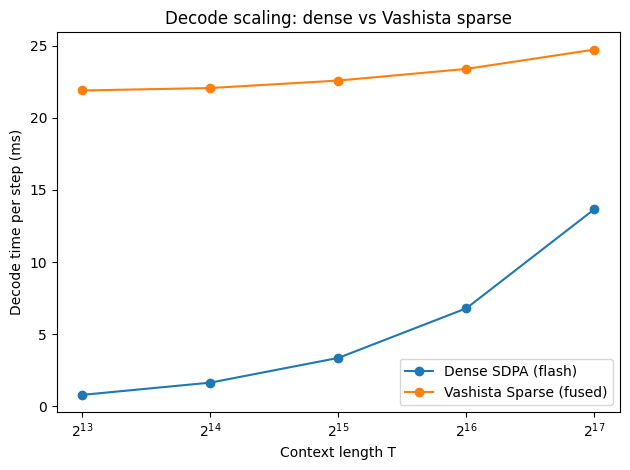

In [9]:

import matplotlib.pyplot as plt, os
os.makedirs("plots", exist_ok=True)
os.makedirs("tables", exist_ok=True)

df = pd.read_csv("tables_scaling.csv")
# Save canonical table
df.to_csv("tables/scaling_decode.csv", index=False)

# Plot
plt.figure()
plt.plot(df["context_len"], df["dense_ms"], marker="o", label="Dense SDPA (flash)")
plt.plot(df["context_len"], df["sparse_ms"], marker="o", label="Vashista Sparse (fused)")
plt.xscale("log", base=2)
plt.xlabel("Context length T")
plt.ylabel("Decode time per step (ms)")
plt.title("Decode scaling: dense vs Vashista sparse")
plt.legend()
plt.tight_layout()
plt.savefig("plots/figure_decode_scaling.pdf")
plt.savefig("plots/figure_decode_scaling.png", dpi=200)
print("Wrote plots/figure_decode_scaling.* and tables/scaling_decode.csv")


## 8) Solver + (P, Kc) ablation sweep
This sweep is small by default; expand ranges for the final paper tables.


In [10]:

import itertools
Ps  = [32, 64, 96]
Kcs = [64, 128, 192]
solvers = ["eg","fw"]
T_ablate = 65536

rows=[]
for solver, P, Kc in itertools.product(solvers, Ps, Kcs):
    r = bench_context(T_ablate, mode_dense="flash", P=P, Kc=Kc, solver=solver, seed=1)
    rows.append(r)
    print("abl", solver, P, Kc, "sparse_ms", r["sparse_ms"], "dense_ms", r["dense_ms"], "speedup", r["speedup"])

df_ab = pd.DataFrame(rows)
df_ab.to_csv("tables/ablation_P_Kc_solver.csv", index=False)
df_ab.head()


abl eg 32 64 sparse_ms 12.472786499998278 dense_ms 6.710782300001483 speedup 0.5380339269017721
abl eg 32 128 sparse_ms 12.459570149999877 dense_ms 6.786119000003055 speedup 0.5446511330893001
abl eg 32 192 sparse_ms 12.625570099999095 dense_ms 6.57805440000061 speedup 0.5210104849048426
abl eg 64 64 sparse_ms 23.26447250000001 dense_ms 6.84582029999774 speedup 0.29426071448633695
abl eg 64 128 sparse_ms 23.288891749999152 dense_ms 6.368933599998172 speedup 0.2734751686927483
abl eg 64 192 sparse_ms 23.37615789999745 dense_ms 6.761511799999198 speedup 0.2892482087486214
abl eg 96 64 sparse_ms 34.2394143000007 dense_ms 6.689586300001338 speedup 0.19537677372013926
abl eg 96 128 sparse_ms 34.21155999999996 dense_ms 6.495185699998274 speedup 0.18985353780997655
abl eg 96 192 sparse_ms 34.12364325000112 dense_ms 6.80169679999949 speedup 0.1993250471577142
abl fw 32 64 sparse_ms 12.701776599999448 dense_ms 6.472378899997011 speedup 0.5095648509514246
abl fw 32 128 sparse_ms 12.7988781999988

,context_len,dense_mode,dense_ms,sparse_ms,speedup,P,Kc,solver
0,65536,flash,6.710782,12.472786,0.538034,32,64,eg
1,65536,flash,6.786119,12.459570,0.544651,32,128,eg
2,65536,flash,6.578054,12.625570,0.521010,32,192,eg
3,65536,flash,6.845820,23.264473,0.294261,64,64,eg
4,65536,flash,6.368934,23.288892,0.273475,64,128,eg


## 9) Heatmaps (paper-ready)
This block produces the heatmaps included in the paper for the two solvers (`eg`, `fw`).

In [11]:

# Heatmaps: TPOT sparse (ms) per solver
import matplotlib.pyplot as plt
for solver in df_ab["solver"].unique():
    sub = df_ab[df_ab["solver"]==solver]
    piv = sub.pivot(index="P", columns="Kc", values="sparse_ms")
    plt.figure()
    plt.imshow(piv.values, aspect="auto")
    plt.xticks(range(len(piv.columns)), piv.columns)
    plt.yticks(range(len(piv.index)), piv.index)
    plt.xlabel("Kc"); plt.ylabel("P")
    plt.title(f"Sparse decode ms @T={T_ablate} — solver={solver}")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(f"plots/heatmap_sparse_ms_{solver}.pdf")
    plt.savefig(f"plots/heatmap_sparse_ms_{solver}.png", dpi=200)
    plt.close()
print("Wrote plots/heatmap_sparse_ms_{eg,fw}.* and tables/ablation_P_Kc_solver.csv")


Wrote plots/heatmap_sparse_ms_{eg,fw}.* and tables/ablation_P_Kc_solver.csv


## 9) Quality: PPL delta + Needle-in-a-haystack (model-based)
This section runs on the actual model to address the 'quality' critique.
It is heavier; run after the kernel/scaling sections.


In [12]:

from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE_Q,
    device_map="auto",
    trust_remote_code=True,
)
model.eval()
print("Loaded model:", MODEL_ID)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Loaded model: DAMO-NLP-SG/Qwen2.5-7B-LongPO-128K


In [13]:

@torch.no_grad()
def windowed_ppl(model, tokenizer, text, stride=2048, max_windows=6):
    enc = tokenizer(text, return_tensors="pt")
    input_ids = enc.input_ids.to("cuda")
    max_len = getattr(model.config, "max_position_embeddings", input_ids.shape[1])

    nlls=[]
    for w, i in enumerate(range(0, min(input_ids.size(1), stride*max_windows), stride)):
        begin_loc = max(i + stride - max_len, 0)
        end_loc   = min(i + stride, input_ids.size(1))
        trg_len   = end_loc - i

        inp = input_ids[:, begin_loc:end_loc]
        tgt = inp.clone()
        tgt[:, :-trg_len] = -100
        out = model(inp, labels=tgt)
        nlls.append(out.loss.detach().float())
    ppl = torch.exp(torch.stack(nlls).mean()).item()
    return ppl

@torch.no_grad()
def needle_test(model, tokenizer, target_tokens=131072):
    import random
    passkey = str(random.randint(10000,99999))
    needle = f"\\n\\nIMPORTANT: the secret passkey is {passkey}.\\n\\n"
    base = "The quick brown fox jumps over the lazy dog. "
    # Tokenize base once to get tokens-per-chunk, then compute reps needed
    base_toks = len(tokenizer.encode(base, add_special_tokens=False))
    n_reps = max(1, (target_tokens // 2 + base_toks - 1) // base_toks)
    garbage = base * n_reps
    prompt = garbage + needle + garbage + "\\n\\nQuestion: what is the secret passkey? Answer with only the number."
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    inp_len = inputs.input_ids.shape[1]
    out = model.generate(**inputs, max_new_tokens=16, do_sample=False, temperature=0.0)
    resp = tokenizer.decode(out[0][inp_len:], skip_special_tokens=True)
    ok = passkey in resp
    return {"success":ok, "passkey":passkey, "response":resp, "prompt_len":inp_len}

# Short text for ppl
text = ("The history of artificial intelligence began in antiquity. " * 4000)[:400000]
print("text chars:", len(text))


text chars: 236000


In [14]:

# Dense quality (no patching here; this section is quality-only for the model)
ppl_dense = windowed_ppl(model, tokenizer, text, stride=2048, max_windows=6)
needle = needle_test(model, tokenizer, target_tokens=NEEDLE_CONTEXT)
print("Dense PPL:", ppl_dense)
print("Needle:", needle["success"], "prompt_len:", needle["prompt_len"], "resp:", needle["response"][:200])


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Dense PPL: 1.004462718963623
Needle: True prompt_len: 119197 resp:  40247\n


## 10) Export artifacts (paper-ready zip)
Bundles all `tables/`, `plots/`, and any `logs/` into a single zip.


In [15]:

import zipfile, os
zip_path = "paper_ready_one_notebook_artifacts.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for root in ["tables","plots","logs"]:
        if not os.path.isdir(root):
            continue
        for dirpath, _, fns in os.walk(root):
            for fn in fns:
                p=os.path.join(dirpath, fn)
                z.write(p, arcname=p)
print("Wrote:", zip_path)


Wrote: paper_ready_one_notebook_artifacts.zip
